run this headless

conda activate guitarmidi
screen  jupyter nbconvert --to notebook --execute traning.ipynb --output=training_out.ipynb --ExecutePreprocessor.timeout=-1 > nbconvert.log 2>&1 &


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import time
from IPython.display import clear_output
from datetime import datetime # Import datetime

# --- Essential for GPU memory management ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")

        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True) # Corrected
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
# ---------------------------------------------------------------------------------

print(f"TensorFlow version: {tf.__version__}")

# --- Configuration (using values from serialization part) ---
image_height = 256
image_width = 312 # Assuming this is your updated 288+some context/padding, or just 288 filter outputs
num_channels = 1
num_classes = 89 # For MIDI notes
INPUT_SHAPE = (image_height, image_width, num_channels)
OUTPUT_DIM_NOTES = num_classes # For notes output
# Removed: OUTPUT_DIM_ONSETS = 1
LEARNING_RATE = 0.001
BATCH_SIZE = 16 # Adjust as needed
EPOCHS = 100

# Directories where slices were saved
input_data_dir = 'data_slices/input'
output_data_dir = 'data_slices/output' # This will be for the 'note' labels
# Removed: onsets_data_dir = 'data_slices/onsets' # This will be for the 'onsets' labels

# --- Custom Callback for Live Loss Plotting (adapted for single output) ---
class JupyterLivePlottingCallback(Callback):
    def __init__(self, fig_title="Training Metrics", base_plot_dir="training_plots"):
        super().__init__()
        self.fig_title = fig_title
        
        # Generate a timestamp for the directory name
        timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
        self.plot_save_dir = os.path.join(base_plot_dir, f"run_{timestamp}")
        
        # Create the directory if it doesn't exist
        os.makedirs(self.plot_save_dir, exist_ok=True)
        print(f"Plots will be saved to: {self.plot_save_dir}")

        self.epoch_data = {
            'loss': [], 'note_output_loss': [], 'note_output_accuracy': [],
            'val_loss': [], 'val_note_output_loss': [], 'val_note_output_accuracy': []
        }
        self.epochs = []

    def on_train_begin(self, logs=None):
        self.epoch_data = {k: [] for k in self.epoch_data.keys()}
        self.epochs = []
        print("Starting Keras model training with live plot. Output will update below...")

    def on_epoch_end(self, epoch, logs=None):
        clear_output(wait=True)

        self.epochs.append(epoch + 1)
        for key in self.epoch_data:
            self.epoch_data[key].append(logs.get(key))

        fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Changed to 1 row, 2 columns

        # Plot Note Accuracy
        axes[0].plot(self.epochs, self.epoch_data['note_output_accuracy'], 'b-o', label='Training Note Accuracy')
        axes[0].plot(self.epochs, self.epoch_data['val_note_output_accuracy'], 'r-x', label='Validation Note Accuracy')
        axes[0].set_title('Note Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].grid(True)
        axes[0].legend(loc='lower right')
        axes[0].set_xticks(self.epochs if len(self.epochs) < 15 else self.epochs[::2])

        # Plot Total Loss
        axes[1].plot(self.epochs, self.epoch_data['loss'], 'b-o', label='Total Training Loss')
        axes[1].plot(self.epochs, self.epoch_data['val_loss'], 'r-x', label='Total Validation Loss')
        axes[1].set_title('Total Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].grid(True)
        axes[1].legend(loc='upper right')
        axes[1].set_xticks(self.epochs if len(self.epochs) < 15 else self.epochs[::2])
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        # Save the plot to a file inside the timestamped directory
        plot_filename = os.path.join(self.plot_save_dir, f"training_plot.png")
        plt.savefig(plot_filename, dpi=150)
        plt.close(fig) # Close the figure to free up memory

        plt.show()

    def on_train_end(self, logs=None):
        print("Training finished. Final plot above.")


# --- 1. Define the Pure CNN Model (single output for notes) ---
def build_cnn_model(input_shape, output_dim_notes): # Removed output_dim_onsets

    inputs = layers.Input(shape=input_shape, dtype=tf.float32, name='input_features')

    # --- Shared Feature Extractor ---
    x = layers.Conv2D(filters=32, kernel_size=(7,7), padding='same', activation=None)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)
    x = layers.SpatialDropout2D(0.2)(x)

    x = layers.Conv2D(filters=64, kernel_size=(7,7), padding='same', activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)
    x = layers.SpatialDropout2D(0.25)(x)
    
    # --- Continue shared feature extraction for the Note branch ---
    x = layers.Conv2D(filters=128, kernel_size=(7, 7), padding='same', activation=None)(x) # Use x_conv_features
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)
    x = layers.SpatialDropout2D(0.3)(x)

    # --- Branch for Note prediction ---
    note_output_branch_features = layers.GlobalAveragePooling2D()(x)
    note_output_branch_features = layers.Dropout(0.4)(note_output_branch_features)

    # No concatenation needed as onsets branch is removed
    note_output = layers.Dense(output_dim_notes, activation='sigmoid', dtype=tf.float32, name='note_output')(note_output_branch_features)

    # Model now has only one output
    return Model(inputs=inputs, outputs=note_output)


# --- 2. Compile the Model (Updated for single output) ---
cnn_model = build_cnn_model(INPUT_SHAPE, OUTPUT_DIM_NOTES) # Removed OUTPUT_DIM_ONSETS

# Define loss functions for the single output
losses = {
    'note_output': 'binary_crossentropy',
}

# Define metrics for the single output
metrics = {
    'note_output': 'accuracy', # or tf.keras.metrics.BinaryAccuracy()
}

# Loss weights are simpler for a single output, can be removed or just kept as 1.0
# Removed: loss_weights = {'note_output': 1.0, 'onsets_output': 2.0}

cnn_model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE,clipnorm=1.0),
                  loss=losses, # Use the dictionary for consistency, even with one item
                  # loss_weights=loss_weights, # Removed for single output
                  metrics=metrics)

cnn_model.summary()

# --- 3. Data Loading and Preparation (Stream from Disk - .npy files) ---

# Get lists of all input and output file paths
input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '*.npy')))
output_filepaths = sorted(glob.glob(os.path.join(output_data_dir, '*.npy'))) # For notes
# Removed: onsets_filepaths = sorted(glob.glob(os.path.join(onsets_data_dir, '*.npy'))) # For onsets

total_samples_on_disk = len(input_filepaths)
if total_samples_on_disk == 0:
    print(f"ERROR: No .npy files found in {input_data_dir}. Please run the serialization script first.")
    exit()
# Simplified check for file count
if total_samples_on_disk != len(output_filepaths):
    print("ERROR: Mismatch in number of input or note output files.")
    exit()

print(f"Found {total_samples_on_disk} files on disk.")
# Removed: class_weights_onsets and related print


# Function to load a single image and its labels from file paths (Updated)
def load_input_from_files(input_path_tensor):
    # Convert TensorFlow string tensors to Python strings
    input_path = input_path_tensor.numpy().decode('utf-8')
    # Load the NumPy arrays
    image = np.load(input_path).astype(np.float32).reshape(INPUT_SHAPE)
    image = tf.ensure_shape(image, INPUT_SHAPE)
    return image

def load_notes_from_files( note_output_path_tensor):
    # Convert TensorFlow string tensors to Python strings
    note_output_path = note_output_path_tensor.numpy().decode('utf-8')
    # Load the NumPy arrays
    note_label = np.load(note_output_path).astype(np.float32).reshape(OUTPUT_DIM_NOTES)
    # Ensure shapes for TensorFlow
    note_label = tf.ensure_shape(note_label, (OUTPUT_DIM_NOTES,))
    return  note_label

# Removed: def load_onsets_from_files(...)

# TensorFlow wrapper function (Updated for single output)
def tf_load_sample_from_files(ipath, nopath): # Removed opath
    image = tf.py_function(
        load_input_from_files, [ipath], [tf.float32]
    )[0]
    note_label = tf.py_function(
        load_notes_from_files, [ nopath], [tf.float32]
    )[0]
    
    # Removed onsets_label, onsets_weights
    # onset_label,onset_weights = tf.py_function(
    #     load_onsets_from_files, [opath], [tf.float32,tf.float32]
    # )

    # Explicitly set shapes here!
    image.set_shape(INPUT_SHAPE)
    note_label.set_shape((OUTPUT_DIM_NOTES,))
    # Removed onset_label.set_shape and onset_weights.set_shape
    
    # Return as (input_data, output_labels)
    # No sample weights needed as class_weights for notes are not implemented here
    return (image, note_label)

# Create a dataset from the lists of file paths (Updated)
dataset = tf.data.Dataset.from_tensor_slices((input_filepaths, output_filepaths)) # Removed onsets_filepaths

# Shuffle the list of paths first
dataset = dataset.shuffle(buffer_size=total_samples_on_disk) # Buffer size for shuffling paths

# Split the dataset into training and validation subsets based on indices
split_ratio = 0.8
num_train = int(total_samples_on_disk * split_ratio)

train_dataset = dataset.take(num_train)
val_dataset = dataset.skip(num_train)

# Map the loading function to the datasets using tf.py_function
train_dataset = train_dataset.map(
    tf_load_sample_from_files,
    num_parallel_calls=tf.data.AUTOTUNE # Load in parallel threads/processes
)
val_dataset = val_dataset.map(
    tf_load_sample_from_files,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Apply batching and prefetching
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- 3. Configure Callbacks (monitor names remain the same as they were already note-focused) ---
early_stopping_acc = EarlyStopping(
    monitor='val_accuracy', # Now just 'val_accuracy' or 'val_note_output_accuracy' depending on Keras version
    patience=10,             # Number of epochs with no improvement
    mode='max',              # 'max' because we want to maximize accuracy
    verbose=1,               # Log when training stops
    restore_best_weights=True # Restore weights from the epoch with the best monitored value.
)

model_checkpoint_acc = ModelCheckpoint(
    'best_model_by_note_acc.keras', # A different filename
    monitor='val_accuracy', # Now just 'val_accuracy'
    mode='max',
    save_best_only=True, # Only save when validation accuracy improves
    verbose=1
)
# --- NEW: ReduceLROnPlateau Callback ---
reduce_lr_on_plateau = ReduceLROnPlateau(
    monitor='val_accuracy', # Now just 'val_accuracy'
    factor=0.5,             # Reduce learning rate by half
    patience=5,             # Number of epochs with no improvement before reducing LR
    mode='max',             # 'max' because we want to maximize accuracy
    min_delta=0.0001,       # Minimum change to qualify as an improvement
    cooldown=0,             # Number of epochs to wait before resuming normal operation after LR has been reduced
    min_lr=0.00001,         # Lower bound on the learning rate
    verbose=1
)
jupyter_live_plot = JupyterLivePlottingCallback(fig_title="Keras Training Progress (Single-Output)")

# --- 4. Training the Model ---
print("\n--- Training Pure CNN Model (Single-Output) ---")
try:
    history_cnn = cnn_model.fit(train_dataset,
                                 epochs=EPOCHS,
                                 validation_data=val_dataset,
                                 callbacks=[model_checkpoint_acc, early_stopping_acc, jupyter_live_plot,reduce_lr_on_plateau])
    # You might want to save the final weights too, or rely on ModelCheckpoint
    cnn_model.save_weights('guitarmidi-single-output-final.weights.h5')
    print("Final model weights saved successfully!")
except Exception as e:
    print(f"An error occurred during training: {e}")


Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 149s 61ms/step - accuracy: 0.6205 - loss: 0.0159 - val_accuracy: 0.7598 - val_loss: 0.0064 - learning_rate: 5.0000e-04
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 17.
Training finished. Final plot above.
Final model weights saved successfully!


KeyError: 'note_output_accuracy'

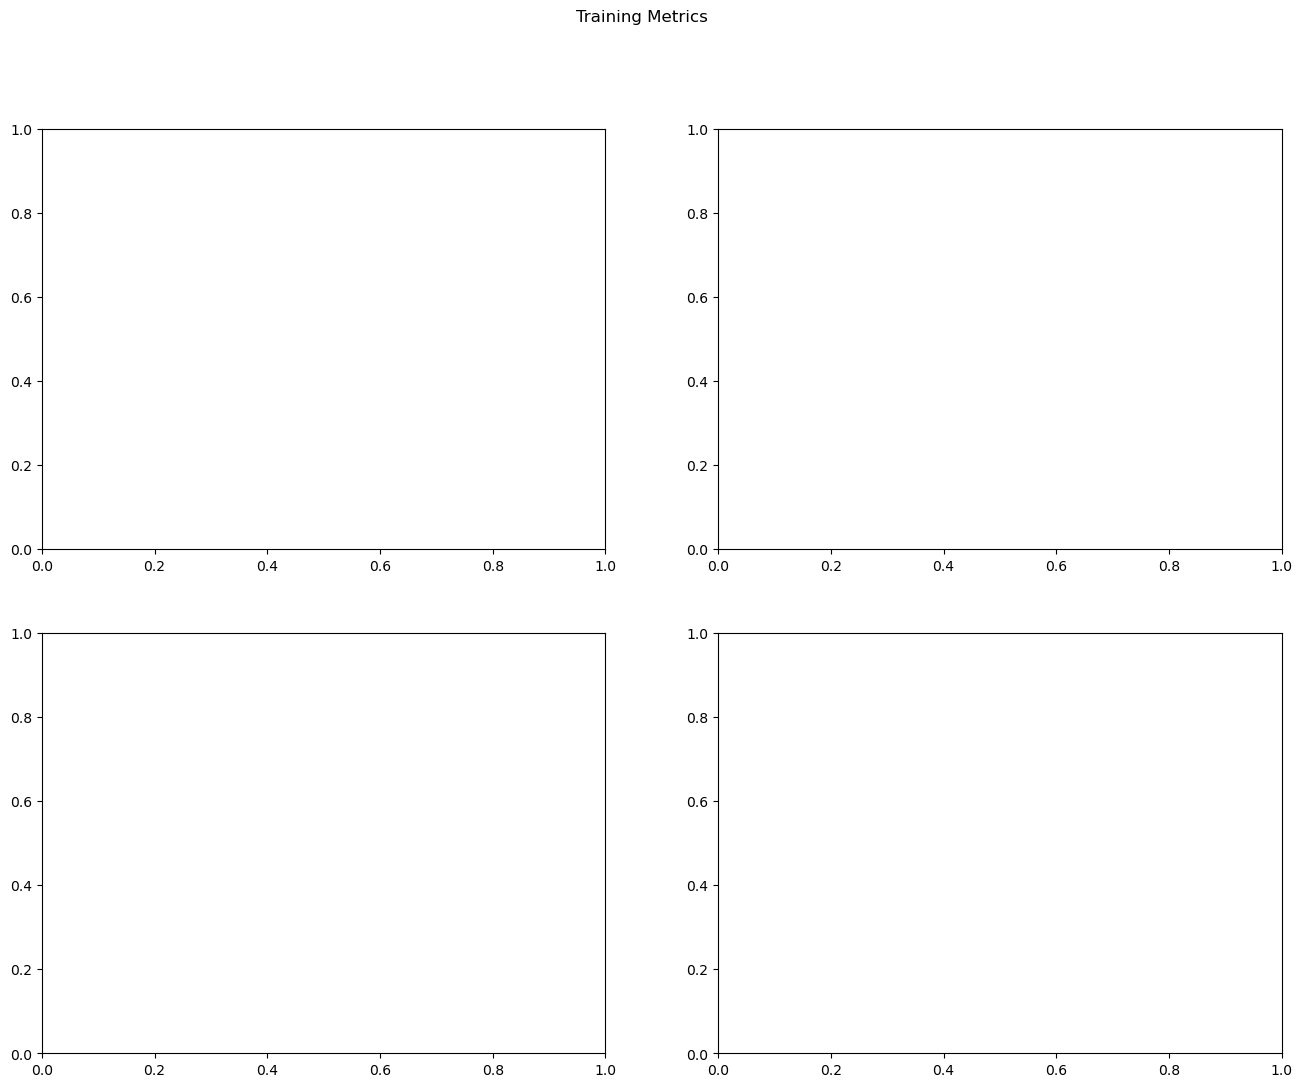

In [2]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_cnn.history['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Training Metrics")

# Note Accuracy
axes[0, 0].plot(epochs, history_cnn.history['note_output_accuracy'], 'b-o', label='Training Note Accuracy')
axes[0, 0].plot(epochs, history_cnn.history['val_note_output_accuracy'], 'r-x', label='Validation Note Accuracy')
axes[0, 0].set_title('Note Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(True)
axes[0, 0].legend(loc='lower right')

# Onsets Accuracy
axes[0, 1].plot(epochs, history_cnn.history['onsets_output_accuracy'], 'b-o', label='Training Onsets Accuracy')
axes[0, 1].plot(epochs, history_cnn.history['val_onsets_output_accuracy'], 'r-x', label='Validation Onsets Accuracy')
axes[0, 1].set_title('Onsets Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].grid(True)
axes[0, 1].legend(loc='lower right')

# Total Loss
axes[1, 0].plot(epochs, history_cnn.history['loss'], 'b-o', label='Total Training Loss')
axes[1, 0].plot(epochs, history_cnn.history['val_loss'], 'r-x', label='Total Validation Loss')
axes[1, 0].set_title('Total Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True)
axes[1, 0].legend(loc='upper right')

# Individual Losses
axes[1, 1].plot(epochs, history_cnn.history['note_output_loss'], 'g-o', label='Training Note Loss')
axes[1, 1].plot(epochs, history_cnn.history['val_note_output_loss'], 'g--x', label='Validation Note Loss')
axes[1, 1].plot(epochs, history_cnn.history['onsets_output_loss'], 'm-o', label='Training Onsets Loss')
axes[1, 1].plot(epochs, history_cnn.history['val_onsets_output_loss'], 'm--x', label='Validation Onsets Loss')
axes[1, 1].set_title('Individual Task Losses')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(True)
axes[1, 1].legend(loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
cnn_model.save_weights('guitarmidi-40-dropout.weights.h5')